# Urban Site Intelligence Agent v2.0 — Real Site Basemap

**Phase 2b+ · Architectural-quality basemap on real Barcelona Eixample site**

> Set `SITE_LAT` / `SITE_LON` below to your Rhino site coordinates.
> Default uses the Eixample chamfered crossroads preset.

| Figure | File | Content |
|--------|------|---------|
| 1 | p2b_basemap.png | Architectural grayscale basemap (real OSM + analysis overlays) |
| 2 | p2a_network.png | Street network centrality |
| 3 | p2a_roads.png | Road importance heatmap |
| 4 | p2a_access.png | Dijkstra accessibility |
| 5 | p2a_corners.png | Corner conditions + visibility cones |


In [1]:
import os, sys, math
from pathlib import Path
import matplotlib
matplotlib.use('Agg')

_cwd = Path(os.getcwd()).resolve()
_root = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent] if (p / 'team_04').is_dir()),
    None,
)
if _root is None:
    raise RuntimeError('Cannot find team_04/ from ' + str(_cwd))
for _p in [str(_root), str(_root.parent)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)
print('Root:', _root)


Root: C:\Users\tuemi\Downloads\Glabtools\IAAC Repo\bimsc26-datamgmt-session03\AIA26_Studio


In [2]:
import warnings, math
from collections import Counter
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from shapely.geometry import LineString, Point, Polygon as SlyPoly
from shapely.ops import unary_union

from team_04.agent.tools.osm_context import (
    fetch_context_or_fallback, build_street_graph, INTERESTING_SITES,
)
from team_04.agent.tools.road_context import analyze_roads
from team_04.agent.tools.site_model import build_site_model
from team_04.agent.tools.urban_analysis import (
    full_urban_analysis, compute_centrality, compute_urban_importance,
    classify_intersection_advanced, detect_intersections_from_roads,
    SITE_TYPE_LABELS,
)

plt.rcParams.update({
    'figure.facecolor': '#F4F0E8', 'axes.facecolor': '#F4F0E8',
    'font.family': 'sans-serif', 'font.size': 10,
    'figure.dpi': 130, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

PAL = dict(
    bg='#F4F0E8', road_main='#ABABAB', road_sec='#C2C2C2', road_path='#D9D9D9',
    sidewalk='#E3E0D8', res='#E07050', com='#5A8CC0', mixed='#68AE5E',
    civic='#9B72C4', ind='#8E8E8E', unk='#C0B49A',
    green='#A2C870', tree_c='#4D8840', site_ec='#D05010', front_hi='#27AE60',
)
BTYPE_COLOR = {
    'residential': PAL['res'], 'commercial': PAL['com'],
    'mixed': PAL['mixed'],     'civic': PAL['civic'],
    'industrial': PAL['ind'],  'unknown': PAL['unk'],
}
HIER_FC   = {'main': PAL['road_main'], 'secondary': PAL['road_sec'], 'path': PAL['road_path']}
HIER_RANK = {'main': 1, 'secondary': 2, 'path': 3}
HIER_OSM  = {'main': 1.0, 'secondary': 0.5, 'path': 0.2}
HIER_AF   = {'main': 0.7, 'secondary': 0.4, 'path': 0.1}
IX_STYLE  = {
    'crossroads':       ('X', '#8B1A1A', 13),
    't_junction':       ('T', '#8B3A1A', 12),
    'y_junction':       ('Y', '#8B6A1A', 12),
    'roundabout':       ('O', '#1A4A8B', 14),
    'complex_junction': ('*', '#6A0572', 12),
    'dead_end':         ('.', '#5A5A5A',  8),
    'bend':             ('.', '#5A5A5A',  7),
}
IX_RESPONSE = {
    'crossroads': (
        'Maximum visibility from 4 directions. '
        'Activate all corners. Retail frontage recommended. '
        'Multiple entrances possible. LANDMARK potential: VERY HIGH.'
    ),
    't_junction': (
        'Building terminates 180 m view corridor. '
        'Primary facade MUST face the approaching axis. '
        'Place entrance at visual termination point. '
        'Architectural focal point required.'
    ),
    'y_junction': (
        'Building mediates two diverging directions. '
        'Dynamic or tapered geometry preferred. '
        'Both arms must be architecturally addressed.'
    ),
    'roundabout': (
        '360-degree visibility. '
        'Landmark architecture strongly encouraged. '
        'No dead facade allowed. Civic or sculptural identity required.'
    ),
    'dead_end': (
        'Lower visibility. Private or residential uses preferred. '
        'No landmark pressure. Quiet threshold condition.'
    ),
    'complex_junction': (
        'Multi-leg convergence. High urban complexity. '
        'Building must anchor the space. Civic or mixed-use program.'
    ),
    'bend': (
        'Curved road creates extended viewshed on outer bend. '
        'Consider angled or curved facade. Moderate landmark potential.'
    ),
}
print('Imports OK')


Imports OK


In [3]:
def _road_poly(road):
    cl = road.get('centerline', []);  w = road.get('width_m', 6.0)
    if len(cl) < 2: return None
    try: return LineString(cl).buffer(w/2, cap_style=2, join_style=2)
    except: return None

def _sidewalk_poly(road):
    cl = road.get('centerline', []); w = road.get('width_m', 6.0)
    h  = road.get('hierarchy', 'path')
    if len(cl) < 2 or h == 'path': return None
    sw = 3.5 if h == 'main' else 2.5
    try:
        return (LineString(cl).buffer(w/2+sw, cap_style=2, join_style=2)
                .difference(LineString(cl).buffer(w/2, cap_style=2, join_style=2)))
    except: return None

def _draw_poly(ax, geom, fc='#CCC', ec='none', alpha=1.0, lw=0.5, zorder=1):
    if geom is None or geom.is_empty: return
    polys = [geom] if geom.geom_type == 'Polygon' else list(getattr(geom, 'geoms', []))
    for p in polys:
        if hasattr(p, 'exterior'):
            xs, ys = p.exterior.xy
            ax.fill(xs, ys, fc=fc, ec=ec, alpha=alpha, linewidth=lw, zorder=zorder)

def _vis_color(s):
    return '#{:02X}{:02X}{:02X}'.format(
        int(244+(42-244)*s), int(226+(157-226)*s), int(133+(143-133)*s))

def _bc_color(s, mn=0, mx=1):
    t = max(0, min(1, (s-mn)/(mx-mn+1e-9)))
    return '#{:02X}{:02X}{:02X}'.format(
        int(37+(212-37)*t), int(99+(37-99)*t), int(212+(37-212)*t))

def _imp_color(s):
    t = max(0, min(1, s))
    return '#{:02X}{:02X}{:02X}'.format(
        int(30+(255-30)*t), int(100+(215-100)*t), int(255+(0-255)*t))

def _draw_cone(ax, apex, dir_deg, half=50, dist=80, fc='#FFD70030', ec='#FFD700', lw=1.2, z=4):
    ang_c = math.radians(dir_deg)
    ang1  = ang_c - math.radians(half)
    ang2  = ang_c + math.radians(half)
    xs = [apex[0]]; ys = [apex[1]]
    for i in range(21):
        a = ang1 + (ang2-ang1)*i/20
        xs.append(apex[0] + dist*math.cos(a))
        ys.append(apex[1] + dist*math.sin(a))
    xs.append(apex[0]); ys.append(apex[1])
    ax.fill(xs, ys, fc=fc, ec=ec, lw=lw, zorder=z)

def _trees_along_roads(roads, spacing=9.0, view=None):
    out = []
    for road in roads:
        if road.get('hierarchy','path') == 'path': continue
        cl = road.get('centerline', [])
        if len(cl) < 2: continue
        line = LineString(cl); w = road.get('width_m', 6.0)
        h = road.get('hierarchy','secondary')
        sw = 3.5 if h=='main' else 2.5; off = w/2 + sw*0.55
        n = max(1, int(line.length/spacing))
        for i in range(n):
            t  = (i+0.4)/n*line.length; pt = line.interpolate(t)
            t2 = min(t+0.5, line.length-0.01); p2 = line.interpolate(t2)
            dx, dy = p2.x-pt.x, p2.y-pt.y; L = math.hypot(dx,dy)+1e-9
            nxv, nyv = -dy/L, dx/L
            for s in (1,-1):
                tx, ty = pt.x+s*nxv*off, pt.y+s*nyv*off
                if view and not (view[0]<=tx<=view[2] and view[1]<=ty<=view[3]): continue
                out.append([tx, ty])
    return out

def _gen_buildings(roads, cx=0, cy=0, rng=150, step=18):
    from shapely.geometry import box
    rp = [_road_poly(r) for r in roads]; rp = [p for p in rp if p and not p.is_empty]
    if not rp: return []
    ru = unary_union(rp)
    cyc = ['residential','residential','commercial','mixed','residential','unknown','commercial','residential']
    out = []
    for xi, bx in enumerate(range(int(cx-rng), int(cx+rng), step)):
        for yi, by in enumerate(range(int(cy-rng), int(cy+rng), step)):
            m=1.5; b=box(bx+m, by+m, bx+step-m, by+step-m)
            if ru.intersects(b): continue
            if not (cx-rng<b.centroid.x<cx+rng and cy-rng<b.centroid.y<cy+rng): continue
            out.append({'building_type': cyc[(xi*7+yi*13)%len(cyc)],
                        'polygon_pts': list(b.exterior.coords), 'name': None})
    return out

def _road_importance(road, bc_vals, graph, max_bc):
    h   = road.get('hierarchy', 'path')
    osm = HIER_OSM.get(h, 0.2)
    af  = HIER_AF.get(h, 0.1)
    bc  = conn = 0.0
    cl  = road.get('centerline', [])
    if cl and bc_vals and graph is not None and len(graph.nodes) > 0:
        mid = cl[len(cl)//2]
        try:
            nid  = min(graph.nodes(), key=lambda n: (graph.nodes[n]['x']-mid[0])**2+(graph.nodes[n]['y']-mid[1])**2)
            bc   = bc_vals.get(nid, 0) / (max_bc or 1)
            conn = min(graph.degree(nid) / 8.0, 1.0)
        except Exception:
            pass
    return round(osm*0.40 + bc*0.30 + conn*0.20 + af*0.10, 4)

def _outward_dir(p1, p2, site_cx, site_cy):
    dx, dy = p2[0]-p1[0], p2[1]-p1[1]
    L = math.hypot(dx, dy) + 1e-9
    nxv, nyv = -dy/L, dx/L
    midx, midy = (p1[0]+p2[0])/2, (p1[1]+p2[1])/2
    if nxv*(midx-site_cx) + nyv*(midy-site_cy) < 0:
        nxv, nyv = -nxv, -nyv
    return math.degrees(math.atan2(nyv, nxv))

print('Helpers ready')


Helpers ready


In [4]:
# ── Paste your real site coordinates here ─────────────────────────────────
# In Rhino: run LatLong command or use Location panel to get lat/lon.
# In Google Maps: right-click the site centroid → copy coordinates.
SITE_LAT    = 41.3936   # ← your latitude
SITE_LON    =  2.1628   # ← your longitude
SITE_RADIUS = 200       # metres — 150-250 gives good Eixample context

SITE_PRESET = {
    'name': 'Real Barcelona Eixample Site',
    'lat': SITE_LAT, 'lon': SITE_LON, 'radius_m': SITE_RADIUS,
    'site_type_hint': 'crossroads',
}
print(f'Site: lat={SITE_LAT}, lon={SITE_LON}, r={SITE_RADIUS} m')

import warnings
with warnings.catch_warnings(record=True) as _w:
    warnings.simplefilter('always')
    ctx = fetch_context_or_fallback(
        SITE_PRESET['lat'], SITE_PRESET['lon'],
        radius_m=SITE_PRESET['radius_m'], fallback_index=0,
    )
if _w: print('Offline fallback -', _w[-1].message)

SOURCE    = ctx['source']
ROADS     = ctx['roads']
BUILDINGS = ctx.get('buildings', [])
GREENS    = ctx.get('green_areas', [])
TREES_OSM = ctx.get('trees', [])
SITE_BDRY = ctx.get('site_boundary', [])
IX_OSM    = ctx.get('intersections', [])

SITE_MODEL   = build_site_model(SITE_BDRY)
ROADS_RESULT = analyze_roads(SITE_MODEL, ROADS)
SITE_MODEL['roads'] = ROADS_RESULT
URBAN     = full_urban_analysis(SITE_MODEL, ROADS, IX_OSM or None)
FRONTAGES = URBAN['frontages']
ACCESS    = URBAN['access']
CORNERS   = URBAN['corner_conditions']
NEAR_IX   = URBAN['nearby_intersections']
RESPONSE  = URBAN['urban_response']
SITE_TYPE = URBAN['site_type']

try:
    G_STREET   = build_street_graph(ROADS)
    CENTRALITY = compute_centrality(G_STREET)
    IMPORTANCE = compute_urban_importance(SITE_MODEL, G_STREET, CENTRALITY)
    NX_OK      = G_STREET is not None and bool(CENTRALITY)
except Exception as _e:
    G_STREET, CENTRALITY, IMPORTANCE, NX_OK = None, {}, {'score':0.5,'grade':'B','factors':{}}, False
    print(f'NetworkX unavailable: {_e}')

all_pts = [p for r in ROADS for p in r.get('centerline',[])] + list(SITE_BDRY)
if all_pts:
    _xs=[p[0] for p in all_pts]; _ys=[p[1] for p in all_pts]
    VIEW_CX=(min(_xs)+max(_xs))/2; VIEW_CY=(min(_ys)+max(_ys))/2
    VIEW_RNG=max(max(_xs)-min(_xs),max(_ys)-min(_ys))/2*1.3+25
else:
    VIEW_CX, VIEW_CY, VIEW_RNG = 0, 0, 160
VIEW = (VIEW_CX-VIEW_RNG, VIEW_CY-VIEW_RNG, VIEW_CX+VIEW_RNG, VIEW_CY+VIEW_RNG)

_corners  = SITE_MODEL.get('corners', [])
_sides    = SITE_MODEL.get('sides', [])
_rp  = [_road_poly(r) for r in ROADS]; _rp = [p for p in _rp if p and not p.is_empty]
_road_u   = unary_union(_rp) if _rp else None
_tree_pts = TREES_OSM if TREES_OSM else _trees_along_roads(ROADS, spacing=9.0, view=VIEW)

if len(SITE_BDRY) >= 3:
    _sp_geom = SlyPoly([(p[0],p[1]) for p in SITE_BDRY])
    SITE_CX, SITE_CY = _sp_geom.centroid.x, _sp_geom.centroid.y
else:
    SITE_CX, SITE_CY = VIEW_CX, VIEW_CY

bc_vals = CENTRALITY.get('betweenness', {}) if CENTRALITY else {}
max_bc  = max(bc_vals.values(), default=1) or 1
for ri, road in enumerate(ROADS):
    road['_score'] = _road_importance(road, bc_vals, G_STREET if NX_OK else None, max_bc)
    road['_id']    = f'R{ri+1:03d}'
RANKED_ROADS = sorted(ROADS, key=lambda r: -r.get('_score', 0))
PRIMARY_ROAD = RANKED_ROADS[0] if RANKED_ROADS else None

ALL_IX = IX_OSM or detect_intersections_from_roads(ROADS)
for ix in ALL_IX:
    if ix.get('degree') == 3 and ix.get('type') in ('t_junction','y_junction',None):
        nr = [r for r in ROADS
              if len(r.get('centerline',[])) >= 2
              and LineString(r['centerline']).distance(Point(ix['point'])) < 8]
        is_rb = any(r.get('is_roundabout') for r in nr)
        ix['type'] = classify_intersection_advanced(3, nr, is_roundabout=is_rb)
ALL_IX_S = sorted(ALL_IX, key=lambda ix: (-ix['point'][1], ix['point'][0]))
for ji, ix in enumerate(ALL_IX_S): ix['_jid'] = f'J{ji+1:03d}'

PATH_NODES, PATH_LEN = [], float('inf')
if NX_OK and PRIMARY_ROAD and G_STREET.number_of_nodes() > 1:
    try:
        site_nd = min(G_STREET.nodes(), key=lambda n:
            (G_STREET.nodes[n]['x']-SITE_CX)**2+(G_STREET.nodes[n]['y']-SITE_CY)**2)
        pcl = PRIMARY_ROAD.get('centerline',[])
        if pcl:
            pm = pcl[len(pcl)//2]
            prim_nd = min(G_STREET.nodes(), key=lambda n:
                (G_STREET.nodes[n]['x']-pm[0])**2+(G_STREET.nodes[n]['y']-pm[1])**2)
            if nx.has_path(G_STREET, site_nd, prim_nd):
                PATH_NODES = nx.shortest_path(G_STREET, site_nd, prim_nd, weight='length')
                PATH_LEN   = nx.shortest_path_length(G_STREET, site_nd, prim_nd, weight='length')
    except Exception as _pe:
        print(f'Dijkstra error: {_pe}')

print(f'Source:{SOURCE} | roads:{len(ROADS)} | bldgs:{len(BUILDINGS)} | ix:{len(ALL_IX)}')
print(f'Site type: {SITE_TYPE_LABELS.get(SITE_TYPE, SITE_TYPE)}')
print(f'Primary road: {PRIMARY_ROAD.get("name","?") if PRIMARY_ROAD else "?"}')
print(f'Urban importance: {IMPORTANCE.get("grade","?")} ({IMPORTANCE.get("score",0):.2f})')
if PATH_NODES: print(f'Dijkstra to primary: {PATH_LEN:.0f} m ({len(PATH_NODES)-1} hops)')


Site: lat=41.3936, lon=2.1628, r=200 m
Offline fallback - OSM rich fetch failed (Overpass API request failed: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter); using synthetic fallback.
Source:synthetic | roads:3 | bldgs:0 | ix:1
Site type: Crossroads Corner
Primary road: Carrer Gran
Urban importance: C (0.36)


In [5]:
# Road classification table
print(f"\n{'='*82}")
print(f"  ROAD CLASSIFICATION TABLE — {SITE_PRESET['name']}")
print(f"{'='*82}")
print(f"  {'Road_ID':<8} {'Road_Name':<24} {'Road_Type':<12} {'Width':>7} {'Lanes':>6} {'Rank':>5} {'Score':>8}")
print(f"  {'-'*75}")
for r in RANKED_ROADS[:18]:
    nm  = r.get('name','[unnamed]') or '[unnamed]'
    h   = r.get('hierarchy','path')
    w   = r.get('width_m', 5.0)
    lns = max(1, round(w / 3.5))
    rk  = HIER_RANK.get(h, 3)
    sc  = r.get('_score', 0)
    rid = r.get('_id', '?')
    print(f"  {rid:<8} {nm[:24]:<24} {h.title():<12} {w:>5.1f} m {lns:>6} {rk:>5} {sc:>8.4f}")
print(f"  {'-'*75}")
hc = Counter(r.get('hierarchy','path') for r in ROADS)
print(f"  Totals: Main={hc.get('main',0)}  Secondary={hc.get('secondary',0)}  Path={hc.get('path',0)}")
print(f"  Primary road: {PRIMARY_ROAD.get('name','?') or '[unnamed]'} | "
      f"{PRIMARY_ROAD.get('hierarchy','?')} | {PRIMARY_ROAD.get('width_m',0):.1f} m wide | "
      f"score={PRIMARY_ROAD.get('_score',0):.4f}" if PRIMARY_ROAD else '')
print(f"{'='*82}")



  ROAD CLASSIFICATION TABLE — Real Barcelona Eixample Site
  Road_ID  Road_Name                Road_Type      Width  Lanes  Rank    Score
  ---------------------------------------------------------------------------
  R001     Carrer Gran              Main          20.0 m      6     1   0.4950
  R002     Avinguda Nord            Secondary     10.0 m      3     2   0.2650
  R003     Passatge Posterior       Path           4.0 m      1     3   0.1150
  ---------------------------------------------------------------------------
  Totals: Main=1  Secondary=1  Path=1
  Primary road: Carrer Gran | main | 20.0 m wide | score=0.4950


Figure 1 saved: p2b_basemap.png

OVERLAY GUIDE:
  Coloured lines on SITE EDGES = Frontage Visibility Scores
    Green  100% = maximum street visibility
    Orange   0% = low street visibility
  [GW]  = Gateway corner — highest public-exposure point on site
  V / P = Vehicle / Pedestrian access points
  J001... = Intersection IDs (referenced in reasoning chain)
  Site type: Crossroads Corner
  2 frontage(s)  |  1 gateway corner(s)


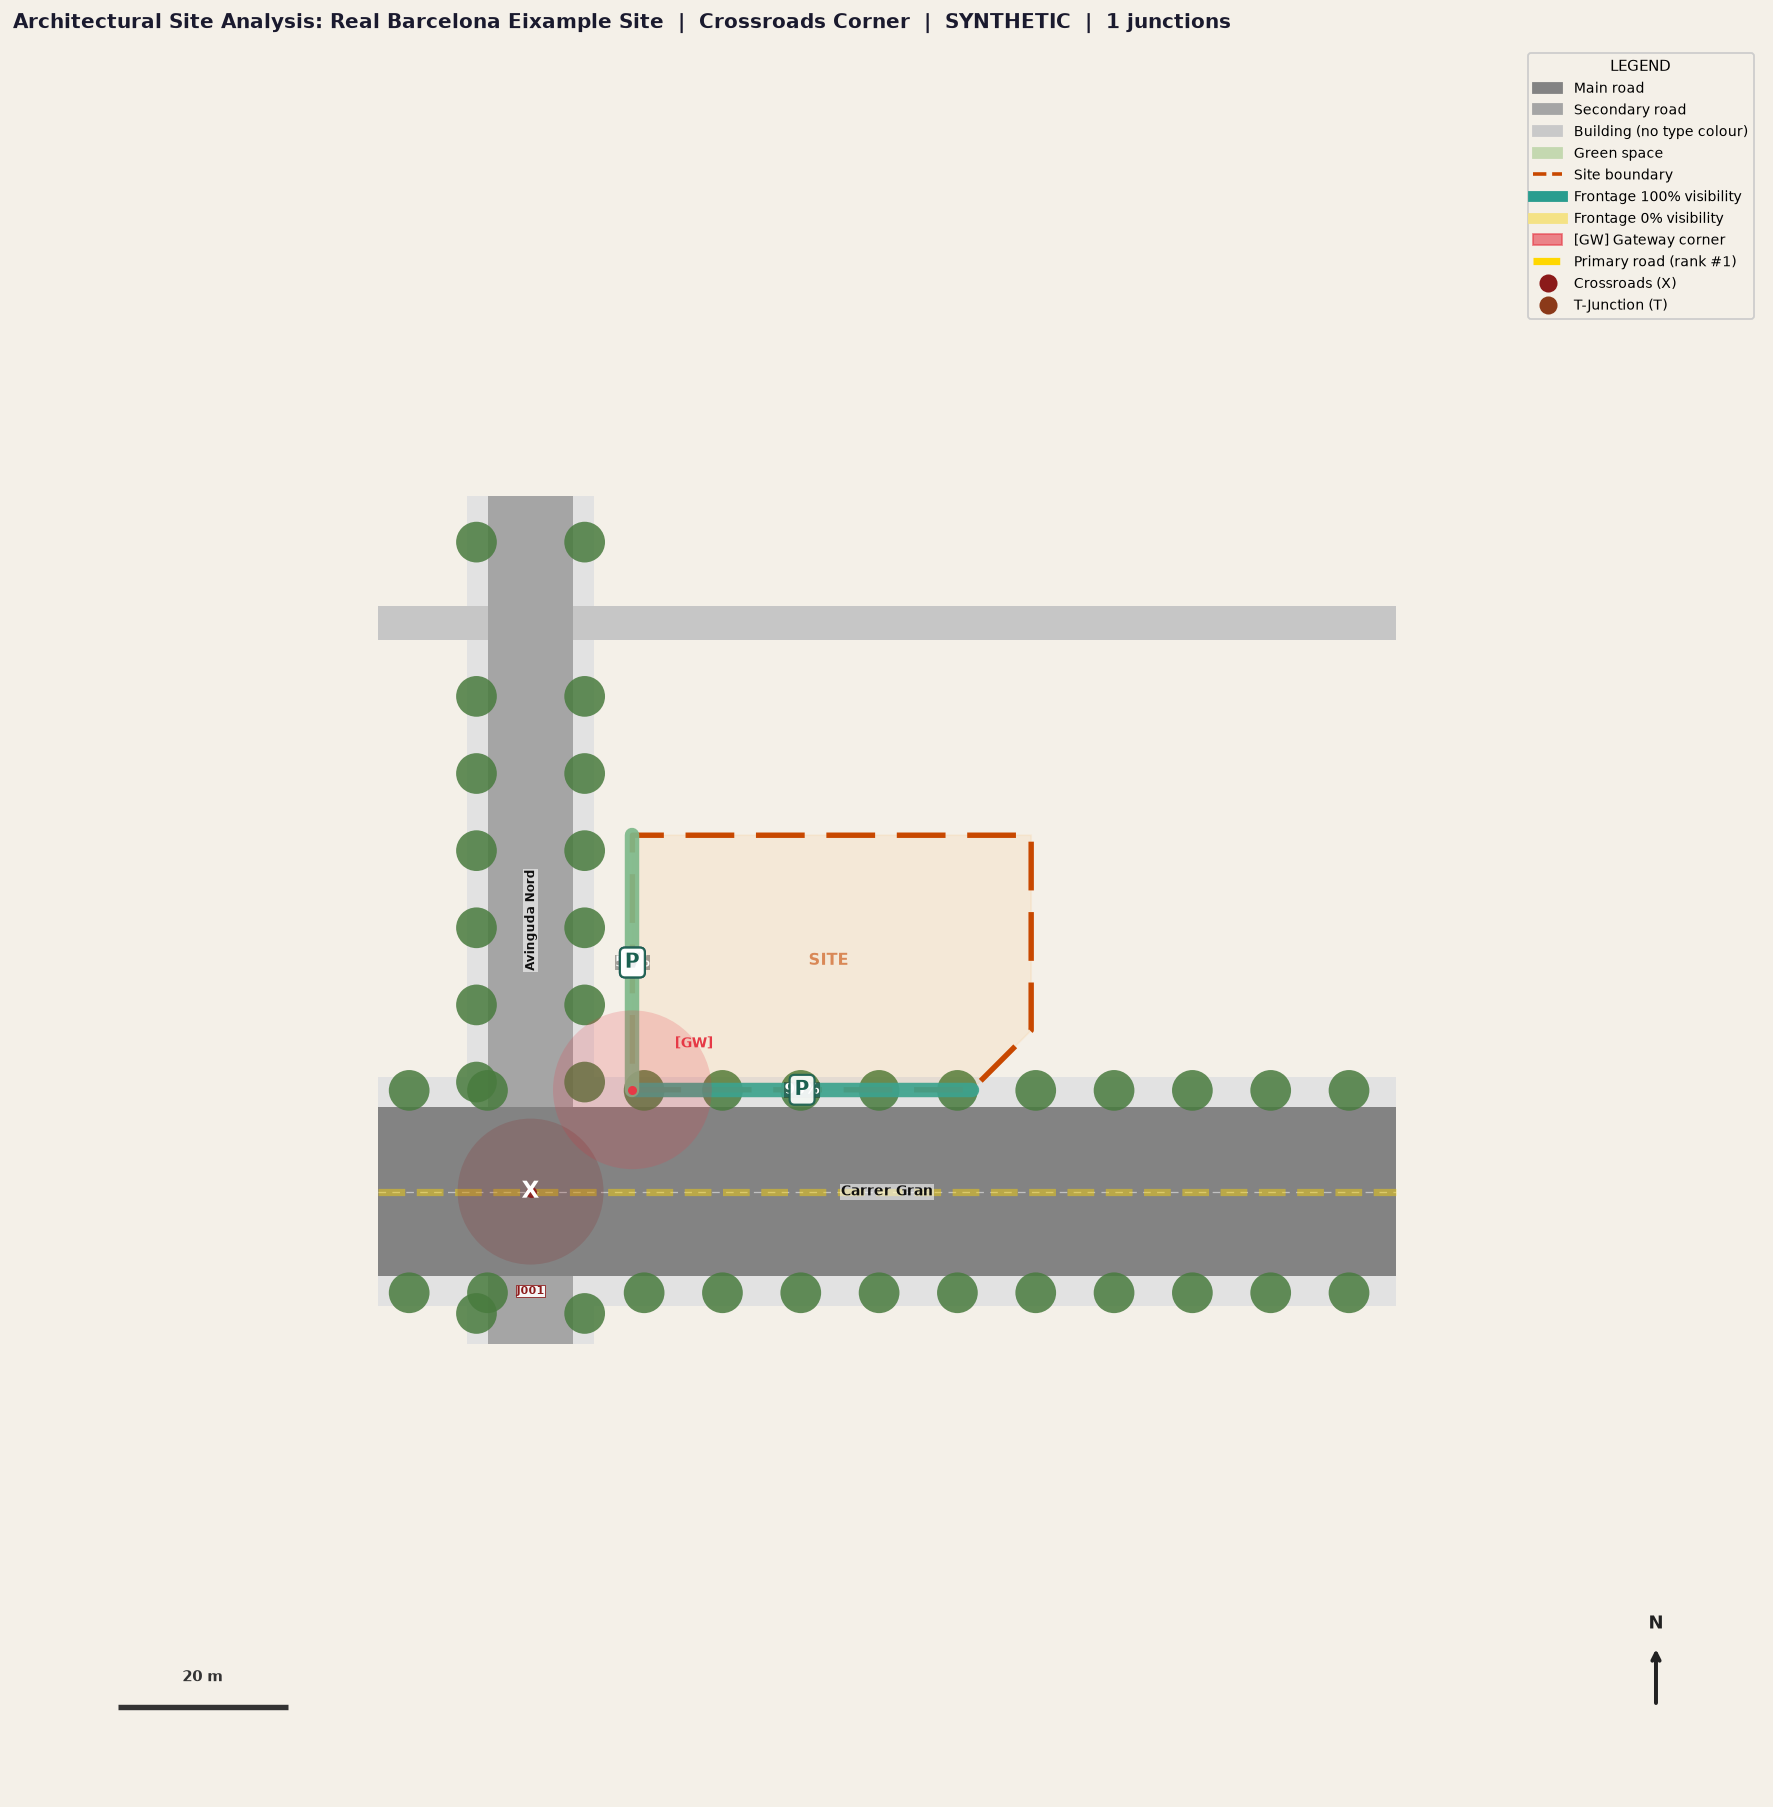

In [6]:
# ============================================================
# Figure 1 — Architectural Basemap (grayscale + analysis overlays)
# ============================================================
# OVERLAY GUIDE — what each coloured element on the site means:
#   Thick coloured edge on site boundary = FRONTAGE VISIBILITY SCORE
#     GREEN  100% = maximum street exposure
#     ORANGE   0% = low street visibility
#   [GW] tag  = GATEWAY CORNER — highest public-exposure corner
#   V marker  = VEHICLE access point
#   P marker  = PEDESTRIAN access point
#   J001...   = INTERSECTION IDs (referenced in reasoning chain below)
#   Gold dash = PRIMARY ROAD (highest-ranked by importance formula)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 14))
ax.set_aspect('equal'); ax.axis('off')
ax.set_xlim(VIEW[0], VIEW[2]); ax.set_ylim(VIEW[1], VIEW[3])
ax.set_facecolor('#EFEFEF')   # architectural cool gray ground

# Green spaces
for ga in GREENS:
    pts = ga.get('polygon_pts', [])
    if len(pts) >= 3:
        _draw_poly(ax, SlyPoly([(p[0],p[1]) for p in pts]),
                   fc='#C4D8B0', ec='none', alpha=0.75, zorder=1)

# Sidewalks
for road in ROADS:
    _draw_poly(ax, _sidewalk_poly(road), fc='#E2E2E2', ec='none', zorder=2)

# Road surfaces — neutral grays
_ROAD_GRAY = {'main': '#838383', 'secondary': '#A5A5A5', 'path': '#C6C6C6'}
for h in ('path', 'secondary', 'main'):
    for road in ROADS:
        if road.get('hierarchy') == h:
            _draw_poly(ax, _road_poly(road), fc=_ROAD_GRAY[h], ec='none', zorder=3)

# Centre-line dashes on main roads
for road in ROADS:
    if road.get('hierarchy') == 'main':
        cl = road.get('centerline', [])
        if len(cl) >= 2:
            ax.plot([p[0] for p in cl], [p[1] for p in cl],
                    color='white', lw=0.7, dashes=(6, 5), alpha=0.5, zorder=4)

# Primary road gold highlight
if PRIMARY_ROAD:
    pcl = PRIMARY_ROAD.get('centerline', [])
    if len(pcl) >= 2:
        ax.plot([p[0] for p in pcl], [p[1] for p in pcl],
                color='#FFD700', lw=4, alpha=0.45, zorder=5, ls='--')

# Buildings — uniform light gray, NO building-type colours
for bldg in BUILDINGS:
    pts = bldg.get('polygon_pts', [])
    if len(pts) < 3: continue
    bp = SlyPoly([(p[0],p[1]) for p in pts])
    if not bp.is_valid: bp = bp.buffer(0)
    if _road_u: bp = bp.difference(_road_u)
    if bp.is_empty: continue
    _draw_poly(ax, SlyPoly([(p[0]+2,p[1]-2) for p in pts]),
               fc='#00000013', ec='none', zorder=6)       # drop shadow
    _draw_poly(ax, bp, fc='#C9C9C9', ec='#B5B5B5', lw=0.5, zorder=7)

# Street trees
for tp in _tree_pts:
    if not (VIEW[0] < tp[0] < VIEW[2] and VIEW[1] < tp[1] < VIEW[3]): continue
    if _road_u and _road_u.contains(Point(tp)): continue
    ax.add_patch(plt.Circle((tp[0], tp[1]), 2.4,
                             color='#487B3E', alpha=0.85, zorder=9, lw=0))

# Site boundary — clear orange dashed outline + subtle fill
if len(SITE_BDRY) >= 3:
    sp = SlyPoly([(p[0],p[1]) for p in SITE_BDRY])
    xs_s, ys_s = sp.exterior.xy
    ax.fill(xs_s, ys_s, color='#FF8C00', alpha=0.07, zorder=10)
    ax.plot(xs_s, ys_s, color='#C84800', lw=3.0, dashes=(9, 4), zorder=11)
    ax.text(sp.centroid.x, sp.centroid.y, 'SITE',
            ha='center', va='center', fontsize=9, color='#C84800',
            fontweight='bold', alpha=0.6, zorder=11)

# Frontage visibility heat lines
for f in FRONTAGES:
    sd = next((s for s in _sides if s.get('edge_index') == f.get('side_index', -1)), None)
    if not sd: continue
    fi = sd.get('from_node_index'); ti = sd.get('to_node_index')
    if fi is None or ti is None or fi >= len(_corners) or ti >= len(_corners): continue
    p1 = _corners[fi]['point']; p2 = _corners[ti]['point']
    vis = f.get('visibility_score', 0.5)
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
            color=_vis_color(vis), lw=8, solid_capstyle='round', alpha=0.92, zorder=12)
    mx_ = (p1[0]+p2[0])/2; my_ = (p1[1]+p2[1])/2
    ax.text(mx_, my_, f'{vis:.0%}',
            ha='center', va='center', fontsize=8.5,
            color='white', fontweight='bold', zorder=13,
            bbox=dict(fc='#00000055', ec='none', pad=0.15))

# Vehicle / pedestrian access points
for cat, sym, col in [('vehicle', 'V', '#1A3A50'), ('pedestrian', 'P', '#1A6050')]:
    for ap in ACCESS.get(cat, []):
        pt = ap.get('point', [])
        if len(pt) >= 2:
            ax.text(pt[0], pt[1], sym,
                    ha='center', va='center', fontsize=11,
                    color=col, fontweight='bold', zorder=14,
                    bbox=dict(fc='white', ec=col, lw=1.2,
                              boxstyle='round,pad=0.25', alpha=0.92))

# Corner conditions
for cc in CORNERS:
    pt = cc['point']
    col = '#E63946' if cc.get('is_gateway') else '#27AE60'
    ax.add_patch(plt.Circle((pt[0], pt[1]),
                             5 + cc['visibility_score'] * 6,
                             color=col, alpha=0.20, zorder=15, lw=0))
    ax.plot(pt[0], pt[1], 'o', color=col, ms=4, zorder=15)
    if cc.get('is_gateway'):
        ax.text(pt[0]+5, pt[1]+5, '[GW]',
                fontsize=7.5, color=col, fontweight='bold', zorder=15)

# Intersection markers with J-IDs
for ix in ALL_IX_S:
    pt = ix['point']; t = ix.get('type', 't_junction')
    sym, col, fs = IX_STYLE.get(t, ('?', '#888', 10))
    jid = ix.get('_jid', 'J?')
    rm = 5 + min(ix.get('degree', 3), 8) * 0.9
    ax.add_patch(plt.Circle((pt[0], pt[1]), rm, color=col, alpha=0.18, zorder=16, lw=0))
    ax.plot(pt[0], pt[1], 'o', color=col, ms=rm*0.6, alpha=0.85, zorder=17)
    ax.text(pt[0], pt[1], sym,
            ha='center', va='center', fontsize=fs,
            color='white', fontweight='bold', zorder=18)
    ax.text(pt[0], pt[1]-rm-2.5, jid,
            ha='center', va='top', fontsize=6,
            color=col, fontweight='bold', zorder=18,
            bbox=dict(fc='white', ec=col, lw=0.5, pad=0.2, alpha=0.9))

# Street name labels
_labeled = set()
for road in ROADS:
    nm = road.get('name'); h = road.get('hierarchy', 'path')
    if not nm or nm in _labeled or h == 'path': continue
    cl = road.get('centerline', [])
    if len(cl) < 2: continue
    mi = len(cl)//2
    mx_ = (cl[mi][0]+cl[mi-1][0])/2; my_ = (cl[mi][1]+cl[mi-1][1])/2
    if not (VIEW[0] < mx_ < VIEW[2] and VIEW[1] < my_ < VIEW[3]): continue
    ang = math.degrees(math.atan2(cl[-1][1]-cl[0][1], cl[-1][0]-cl[0][0]))
    if ang > 90: ang -= 180
    if ang < -90: ang += 180
    ax.text(mx_, my_, nm,
            ha='center', va='center',
            fontsize=8 if h=='main' else 6.5,
            rotation=ang, rotation_mode='anchor',
            color='#111111', fontweight='bold', zorder=19,
            bbox=dict(fc='#FFFFFF90', ec='none', pad=0.4))
    _labeled.add(nm)

# Scale bar + North arrow
sb_v = max(10, int(VIEW_RNG/4/10)*10)
sb_x = VIEW[0]+VIEW_RNG*0.12; sb_y = VIEW[1]+VIEW_RNG*0.10
ax.plot([sb_x, sb_x+sb_v], [sb_y, sb_y], color='#333', lw=3,
        solid_capstyle='butt', zorder=20)
ax.text(sb_x+sb_v/2, sb_y+3, f'{sb_v} m',
        ha='center', fontsize=8.5, color='#333', fontweight='bold')
na_x = VIEW[2]-VIEW_RNG*0.12; na_y = VIEW[1]+VIEW_RNG*0.10
al = VIEW_RNG*0.07
ax.annotate('', xy=(na_x, na_y+al), xytext=(na_x, na_y),
            arrowprops=dict(arrowstyle='->', color='#222', lw=2.2), zorder=20)
ax.text(na_x, na_y+al+2, 'N', ha='center', fontsize=10,
        color='#222', fontweight='bold')

# Legend
leg = [
    mpatches.Patch(color='#838383', label='Main road'),
    mpatches.Patch(color='#A5A5A5', label='Secondary road'),
    mpatches.Patch(color='#C9C9C9', label='Building (no type colour)'),
    mpatches.Patch(color='#C4D8B0', label='Green space'),
    Line2D([],[],color='#C84800',lw=2,ls='--',label='Site boundary'),
    Line2D([],[],color=_vis_color(1.0),lw=6,label='Frontage 100% visibility'),
    Line2D([],[],color=_vis_color(0.0),lw=6,label='Frontage 0% visibility'),
    mpatches.Patch(color='#E63946',alpha=0.6,label='[GW] Gateway corner'),
    Line2D([],[],color='#FFD700',lw=4,ls='--',label='Primary road (rank #1)'),
    Line2D([],[],marker='o',color='#8B1A1A',ls='none',ms=9,label='Crossroads (X)'),
    Line2D([],[],marker='o',color='#8B3A1A',ls='none',ms=9,label='T-Junction (T)'),
]
ax.legend(handles=leg, loc='upper right', fontsize=8,
          framealpha=0.96, edgecolor='#CCCCCC',
          title='LEGEND', title_fontsize=8.5)

ax.set_title(
    f"Architectural Site Analysis: {SITE_PRESET['name']}  |  "
    f"{SITE_TYPE_LABELS.get(SITE_TYPE, SITE_TYPE)}  |  "
    f"{SOURCE.upper()}  |  {len(ALL_IX)} junctions",
    fontsize=11, fontweight='bold', color='#1A1A2E', pad=10, loc='left',
)
plt.tight_layout()
plt.savefig('p2b_basemap.png')
plt.show()
print('Figure 1 saved: p2b_basemap.png')
print()
print('OVERLAY GUIDE:')
print('  Coloured lines on SITE EDGES = Frontage Visibility Scores')
print('    Green  100% = maximum street visibility')
print('    Orange   0% = low street visibility')
print('  [GW]  = Gateway corner — highest public-exposure point on site')
print('  V / P = Vehicle / Pedestrian access points')
print('  J001... = Intersection IDs (referenced in reasoning chain)')
print(f'  Site type: {SITE_TYPE_LABELS.get(SITE_TYPE, SITE_TYPE)}')
print(f'  {len(FRONTAGES)} frontage(s)  |  '
      f'{sum(1 for c in CORNERS if c.get("is_gateway"))} gateway corner(s)')


Figure 2 saved: p2a_network.png


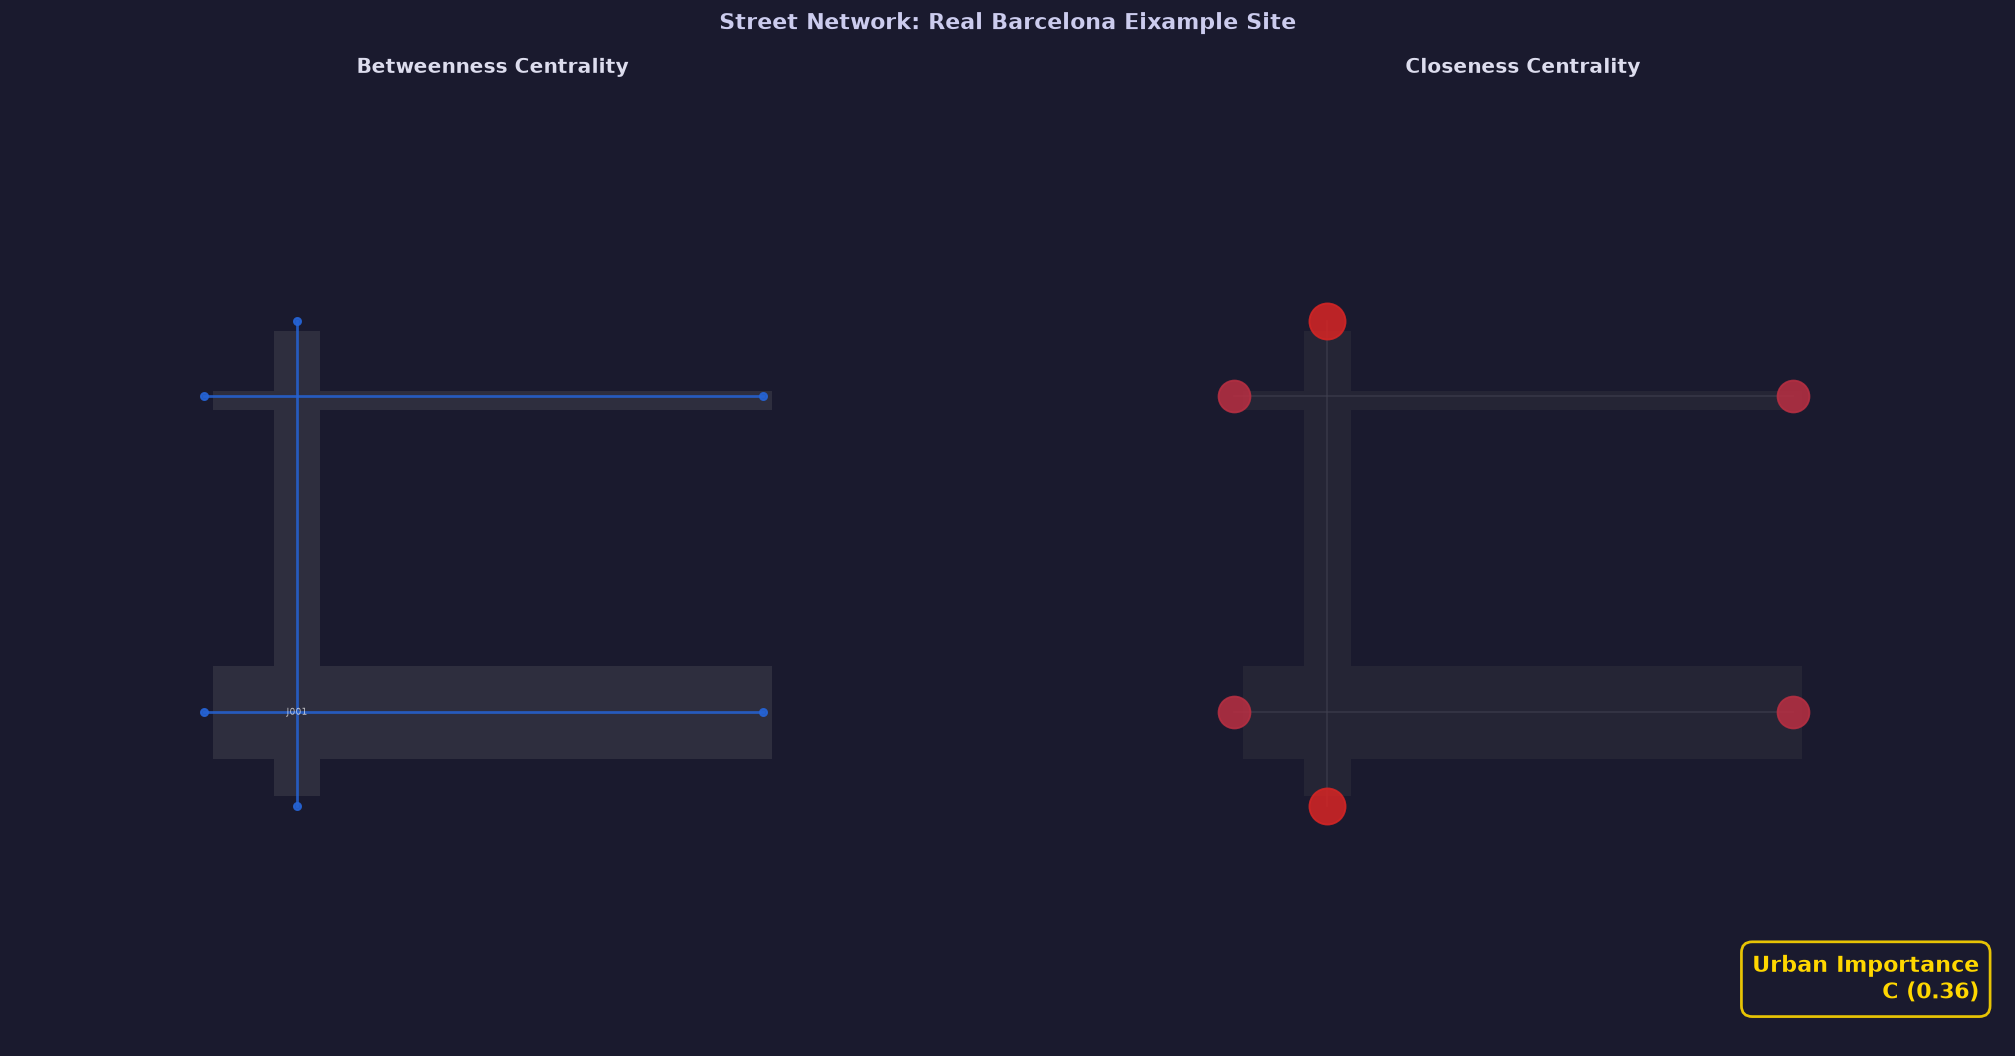

In [7]:
# Figure 2 — Street Network Centrality (dark background)
fig,axes=plt.subplots(1,2,figsize=(16,8))
fig.patch.set_facecolor('#1A1A2E')
for ax in axes:
    ax.set_aspect('equal'); ax.axis('off'); ax.set_facecolor('#1A1A2E')
    ax.set_xlim(VIEW[0],VIEW[2]); ax.set_ylim(VIEW[1],VIEW[3])

if NX_OK:
    bv=CENTRALITY.get('betweenness',{}); cv=CENTRALITY.get('closeness',{})
    mb=max(bv.values(),default=1) or 1
    ax0=axes[0]
    for road in ROADS: _draw_poly(ax0,_road_poly(road),fc='#2E2E3E',ec='none',zorder=1)
    for u,v in G_STREET.edges():
        sc=(bv.get(u,0)+bv.get(v,0))/2
        ax0.plot([G_STREET.nodes[u]['x'],G_STREET.nodes[v]['x']],
                 [G_STREET.nodes[u]['y'],G_STREET.nodes[v]['y']],
                 color=_bc_color(sc,0,mb),lw=1.5+sc/mb*4,alpha=0.85,zorder=2)
    for nid,data in G_STREET.nodes(data=True):
        bn=bv.get(nid,0)
        ax0.plot(data['x'],data['y'],'o',color=_bc_color(bn,0,mb),ms=4+bn/mb*10,alpha=0.9,zorder=3)
    for ix in ALL_IX_S:
        pt=ix['point']
        ax0.text(pt[0],pt[1],ix.get('_jid',''),ha='center',va='center',fontsize=5,color='#FFFFFFAA',zorder=4)
    ax0.set_title('Betweenness Centrality',fontsize=11,color='#DDDDEE',fontweight='bold')

    ax1=axes[1]
    for road in ROADS: _draw_poly(ax1,_road_poly(road),fc='#252535',ec='none',zorder=1)
    for u,v in G_STREET.edges():
        ax1.plot([G_STREET.nodes[u]['x'],G_STREET.nodes[v]['x']],
                 [G_STREET.nodes[u]['y'],G_STREET.nodes[v]['y']],
                 color='#404050',lw=1.0,alpha=0.6,zorder=2)
    for nid,data in G_STREET.nodes(data=True):
        cn=cv.get(nid,0)
        ax1.plot(data['x'],data['y'],'o',color=_bc_color(cn,0,1),ms=6+cn*14,alpha=0.88,zorder=3)
    sc_v=IMPORTANCE.get('score',0)
    ax1.text(VIEW[2]-5,VIEW[1]+8,
             f"Urban Importance\n{IMPORTANCE.get('grade','?')} ({sc_v:.2f})",
             ha='right',va='bottom',fontsize=12,color='#FFD700',fontweight='bold',
             bbox=dict(fc='#1A1A2E',ec='#FFD700',lw=1.5,boxstyle='round,pad=0.5',alpha=0.9))
    ax1.set_title('Closeness Centrality',fontsize=11,color='#DDDDEE',fontweight='bold')
else:
    for ax in axes:
        ax.text(0.5,0.5,'NetworkX not available',ha='center',va='center',fontsize=14,color='#AAAACC',transform=ax.transAxes)

fig.suptitle(f"Street Network: {SITE_PRESET['name']}",fontsize=12,fontweight='bold',color='#CCCCEE',y=1.01)
plt.tight_layout(); plt.savefig('p2a_network.png'); plt.show()
print('Figure 2 saved: p2a_network.png')


Figure 3 saved: p2a_roads.png


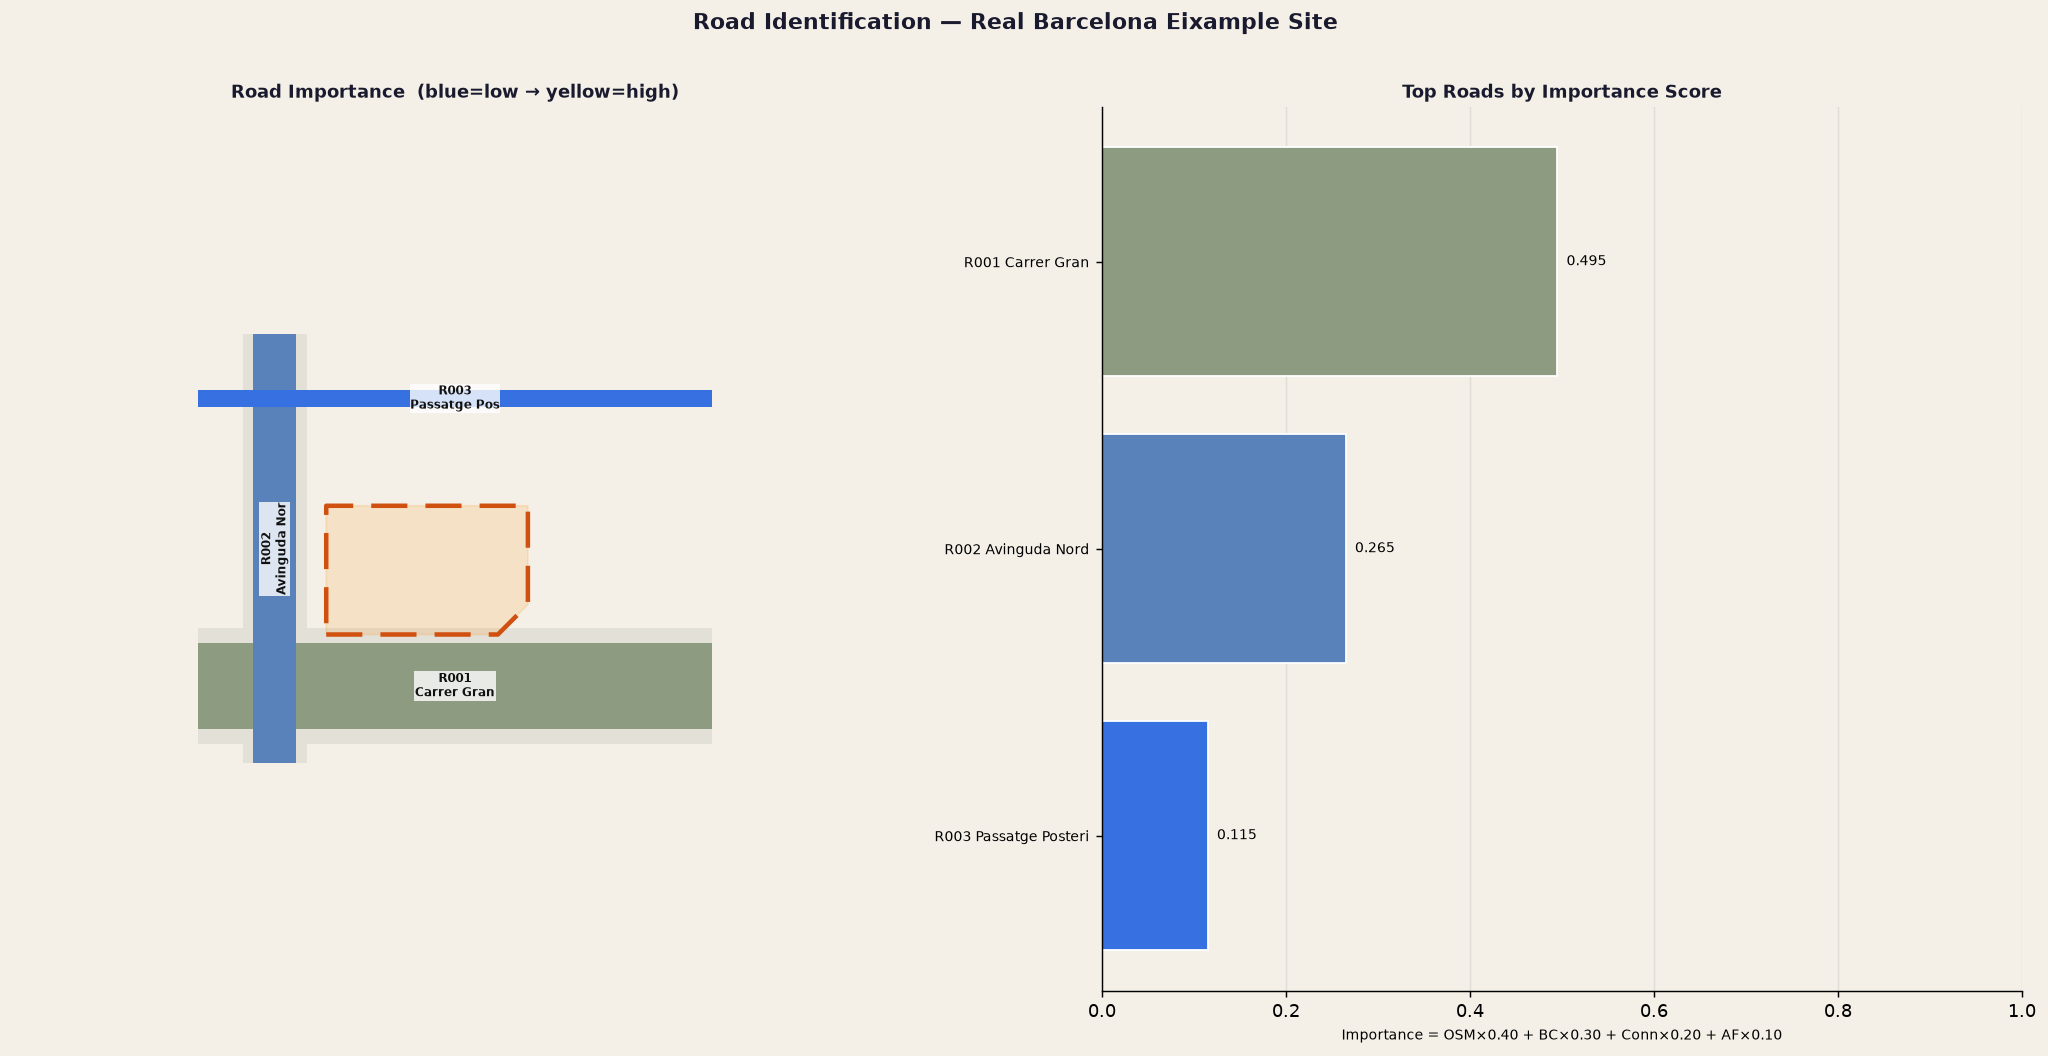

In [8]:
# Figure 3 — Road importance: spatial heatmap + ranked bar chart
fig,axes=plt.subplots(1,2,figsize=(16,8)); fig.patch.set_facecolor(PAL['bg'])

ax0=axes[0]; ax0.set_aspect('equal'); ax0.axis('off')
ax0.set_xlim(VIEW[0],VIEW[2]); ax0.set_ylim(VIEW[1],VIEW[3]); ax0.set_facecolor('#F0EDE6')
for road in ROADS:
    _draw_poly(ax0,_sidewalk_poly(road),fc=PAL['sidewalk'],ec='none',zorder=1)
    rp=_road_poly(road)
    if rp: _draw_poly(ax0,rp,fc=_imp_color(road.get('_score',0)),ec='none',zorder=2)
if len(SITE_BDRY)>=3:
    sp=SlyPoly([(p[0],p[1]) for p in SITE_BDRY]); xs_s,ys_s=sp.exterior.xy
    ax0.fill(xs_s,ys_s,color='#FF8C00',alpha=0.15,zorder=4)
    ax0.plot(xs_s,ys_s,color=PAL['site_ec'],lw=2.5,dashes=(8,4),zorder=5)
_labeled=set()
for road in RANKED_ROADS[:6]:
    nm=road.get('name'); cl=road.get('centerline',[])
    if not nm or nm in _labeled or len(cl)<2: continue
    mi=len(cl)//2; mx_=(cl[mi][0]+cl[mi-1][0])/2; my_=(cl[mi][1]+cl[mi-1][1])/2
    if not (VIEW[0]<mx_<VIEW[2] and VIEW[1]<my_<VIEW[3]): continue
    ang=math.degrees(math.atan2(cl[-1][1]-cl[0][1],cl[-1][0]-cl[0][0]))
    if ang>90: ang-=180
    if ang<-90: ang+=180
    ax0.text(mx_,my_,f"{road.get('_id','?')}\n{nm[:12]}",ha='center',va='center',
             fontsize=6.5,rotation=ang,rotation_mode='anchor',color='#111',fontweight='bold',zorder=6,
             bbox=dict(fc='#FFFFFFCC',ec='none',pad=0.3))
    _labeled.add(nm)
ax0.set_title('Road Importance  (blue=low → yellow=high)',fontsize=10,fontweight='bold',color='#1A1A2E',pad=5)

ax1=axes[1]; ax1.set_facecolor(PAL['bg'])
top_n=RANKED_ROADS[:14]
names=[f"{r.get('_id','?')} {(r.get('name') or r.get('hierarchy','?'))[:16]}" for r in top_n]
scores=[r.get('_score',0) for r in top_n]
ax1.barh(range(len(top_n)),scores,color=[_imp_color(s) for s in scores],edgecolor='white',lw=1)
ax1.set_yticks(list(range(len(top_n)))); ax1.set_yticklabels(names,fontsize=8)
ax1.invert_yaxis()
ax1.set_xlabel('Importance = OSM×0.40 + BC×0.30 + Conn×0.20 + AF×0.10',fontsize=8)
ax1.set_xlim(0,1.0); ax1.spines[['top','right']].set_visible(False)
ax1.xaxis.grid(True,color='#E0DDD8',zorder=0); ax1.set_axisbelow(True)
for i,s in enumerate(scores): ax1.text(s+0.01,i,f'{s:.3f}',va='center',fontsize=7.5)
ax1.set_title('Top Roads by Importance Score',fontsize=10,fontweight='bold',color='#1A1A2E',pad=5)

fig.suptitle(f"Road Identification — {SITE_PRESET['name']}",fontsize=12,fontweight='bold',color='#1A1A2E',y=1.01)
plt.tight_layout(); plt.savefig('p2a_roads.png'); plt.show()
print('Figure 3 saved: p2a_roads.png')


Figure 4 saved: p2a_access.png


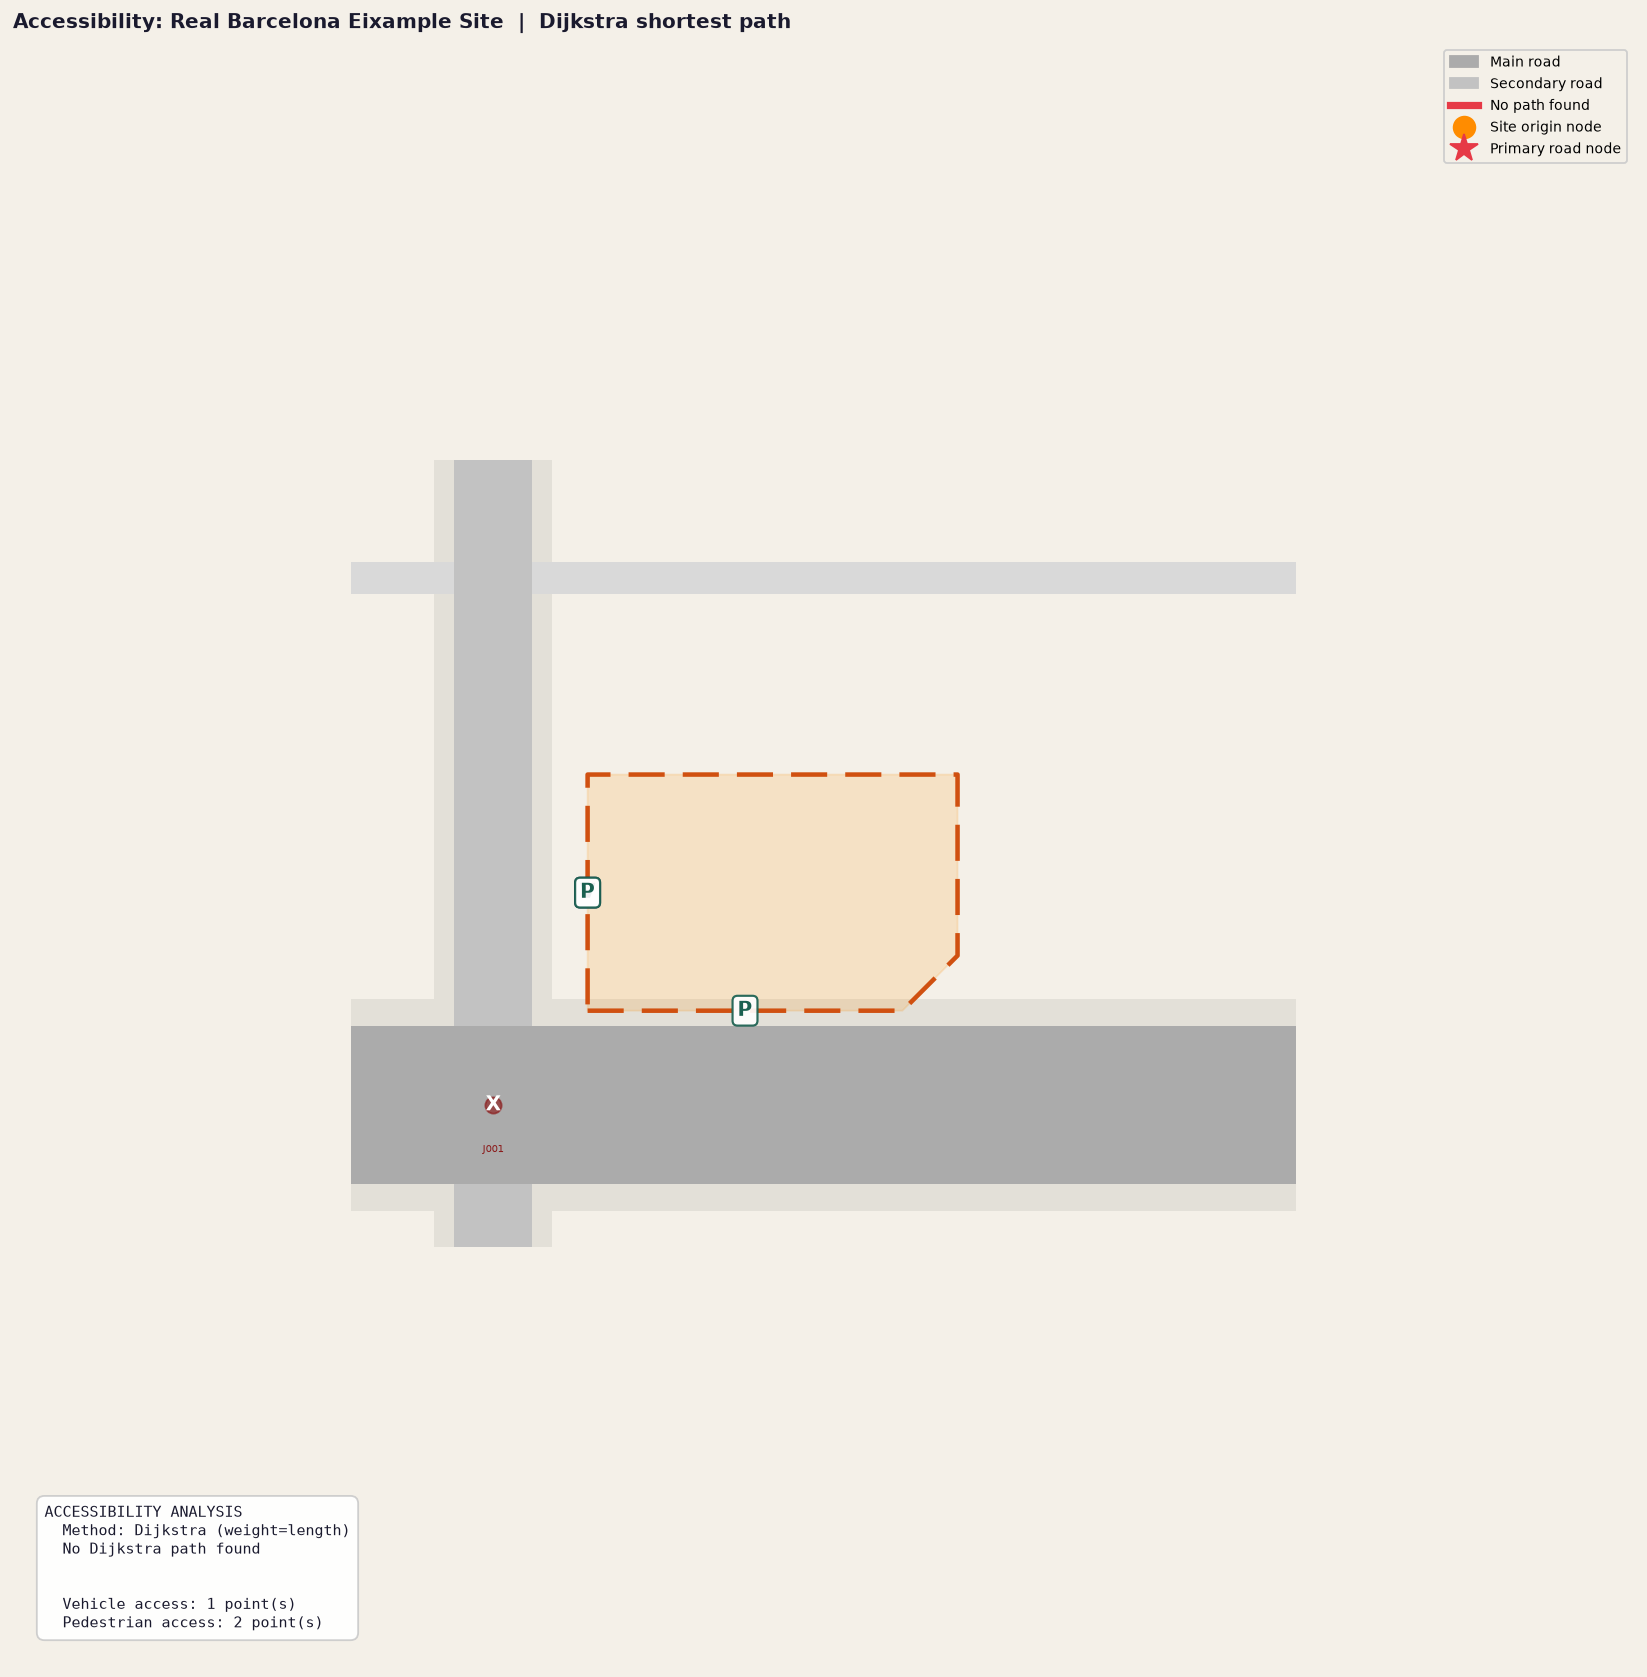

In [9]:
# Figure 4 — Accessibility paths (Dijkstra)
fig,ax=plt.subplots(figsize=(13,13))
ax.set_aspect('equal'); ax.axis('off')
ax.set_xlim(VIEW[0],VIEW[2]); ax.set_ylim(VIEW[1],VIEW[3]); ax.set_facecolor('#F0EDE6')

for road in ROADS: _draw_poly(ax,_sidewalk_poly(road),fc=PAL['sidewalk'],ec='none',zorder=1)
for h in ('path','secondary','main'):
    for road in ROADS:
        if road.get('hierarchy')==h: _draw_poly(ax,_road_poly(road),fc=HIER_FC[h],ec='none',zorder=2)

if len(SITE_BDRY)>=3:
    sp=SlyPoly([(p[0],p[1]) for p in SITE_BDRY]); xs_s,ys_s=sp.exterior.xy
    ax.fill(xs_s,ys_s,color='#FF8C00',alpha=0.15,zorder=4)
    ax.plot(xs_s,ys_s,color=PAL['site_ec'],lw=2.5,dashes=(8,4),zorder=5)

if PATH_NODES and len(PATH_NODES)>=2 and NX_OK:
    px=[G_STREET.nodes[n]['x'] for n in PATH_NODES]
    py=[G_STREET.nodes[n]['y'] for n in PATH_NODES]
    ax.plot(px,py,color='#E63946',lw=4,solid_capstyle='round',zorder=8,label=f'Primary road ({PATH_LEN:.0f} m)')
    ax.plot(px[0],py[0],'o',color='#FF8C00',ms=13,zorder=9)
    ax.plot(px[-1],py[-1],'*',color='#E63946',ms=18,zorder=9)
    mid_i=len(PATH_NODES)//2
    ax.text(px[mid_i],py[mid_i]+5,f'{PATH_LEN:.0f} m\n{len(PATH_NODES)-1} hops',
            ha='center',fontsize=9,color='#E63946',fontweight='bold',zorder=10,
            bbox=dict(fc='white',ec='#E63946',lw=1,pad=0.4,alpha=0.93))

for ix in ALL_IX_S:
    pt=ix['point']; t=ix.get('type','t_junction')
    sym,col,fs=IX_STYLE.get(t,('?','#888',10))
    jid=ix.get('_jid','J?')
    ax.plot(pt[0],pt[1],'o',color=col,ms=9,alpha=0.65,zorder=6)
    ax.text(pt[0],pt[1],sym,ha='center',va='center',fontsize=fs-2,color='white',fontweight='bold',zorder=7)
    ax.text(pt[0],pt[1]-5,jid,ha='center',va='top',fontsize=5.5,color=col,zorder=7)

for cat,sym,col in [('vehicle','V','#1A3A50'),('pedestrian','P','#1A6050')]:
    for ap in ACCESS.get(cat,[]):
        pt=ap.get('point',[])
        if len(pt)>=2:
            ax.text(pt[0],pt[1],sym,ha='center',va='center',fontsize=11,color=col,fontweight='bold',zorder=11,
                    bbox=dict(fc='white',ec=col,lw=1.2,boxstyle='round,pad=0.25',alpha=0.92))

info=[
    'ACCESSIBILITY ANALYSIS',
    f'  Method: Dijkstra (weight=length)',
    f'  To primary road: {PATH_LEN:.0f} m' if PATH_NODES else '  No Dijkstra path found',
    f'  Hops: {len(PATH_NODES)-1}' if PATH_NODES else '',
    '',
    f'  Vehicle access: {len(ACCESS.get("vehicle",[]))} point(s)',
    f'  Pedestrian access: {len(ACCESS.get("pedestrian",[]))} point(s)',
]
ax.text(VIEW[0]+4,VIEW[1]+4,'\n'.join(l for l in info),
        ha='left',va='bottom',fontsize=8.5,color='#1A1A2E',family='monospace',zorder=12,
        bbox=dict(fc='white',ec='#CCC',lw=1,boxstyle='round,pad=0.5',alpha=0.94))

leg=[
    mpatches.Patch(color=PAL['road_main'],label='Main road'),
    mpatches.Patch(color=PAL['road_sec'],label='Secondary road'),
    Line2D([],[],color='#E63946',lw=4,label=f'Dijkstra path ({PATH_LEN:.0f} m)' if PATH_NODES else 'No path found'),
    Line2D([],[],marker='o',color='#FF8C00',ls='none',ms=12,label='Site origin node'),
    Line2D([],[],marker='*',color='#E63946',ls='none',ms=16,label='Primary road node'),
]
ax.legend(handles=leg,loc='upper right',fontsize=8,framealpha=0.93,edgecolor='#CCC')
ax.set_title(f"Accessibility: {SITE_PRESET['name']}  |  Dijkstra shortest path",
             fontsize=11,fontweight='bold',color='#1A1A2E',pad=8,loc='left')
plt.tight_layout(); plt.savefig('p2a_access.png'); plt.show()
print('Figure 4 saved: p2a_access.png')


Figure 5 saved: p2a_corners.png


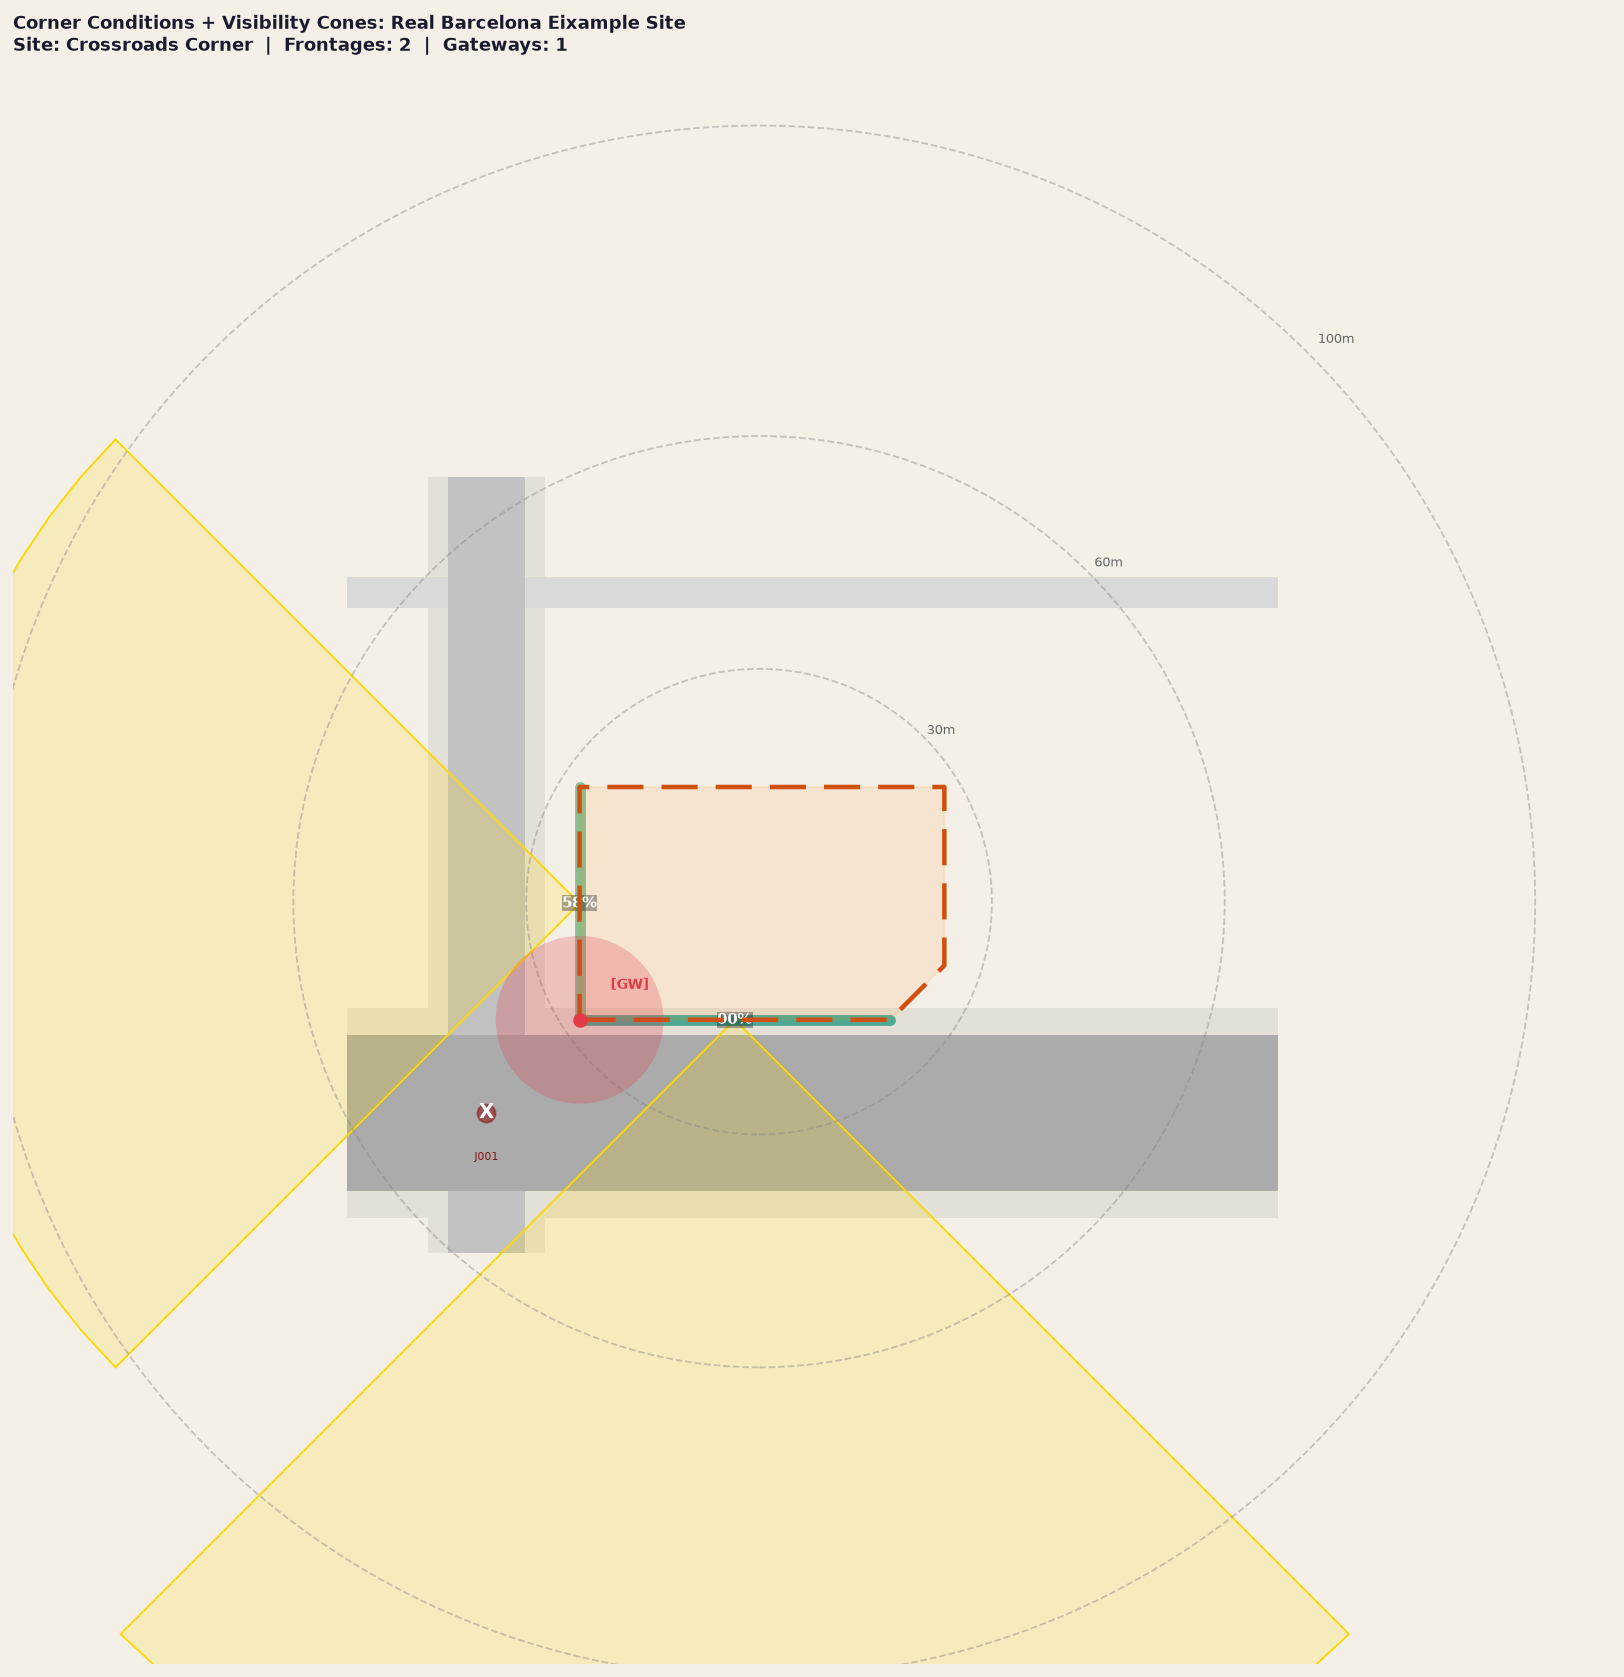

In [10]:
# Figure 5 — Corner conditions + visibility cones
fig,ax=plt.subplots(figsize=(13,13))
ax.set_aspect('equal'); ax.axis('off')
ax.set_xlim(VIEW[0],VIEW[2]); ax.set_ylim(VIEW[1],VIEW[3]); ax.set_facecolor('#ECEADE')

for road in ROADS: _draw_poly(ax,_sidewalk_poly(road),fc=PAL['sidewalk'],ec='none',zorder=1)
for h in ('path','secondary','main'):
    for road in ROADS:
        if road.get('hierarchy')==h: _draw_poly(ax,_road_poly(road),fc=HIER_FC[h],ec='none',zorder=2)

# Visibility cones from each frontage (outward normal, dist scales with visibility)
for f in FRONTAGES:
    sd=next((s for s in _sides if s.get('edge_index')==f.get('side_index',-1)),None)
    if not sd: continue
    fi=sd.get('from_node_index'); ti=sd.get('to_node_index')
    if fi is None or ti is None or fi>=len(_corners) or ti>=len(_corners): continue
    p1=_corners[fi]['point']; p2=_corners[ti]['point']
    vis=f.get('visibility_score',0.5)
    out_dir=_outward_dir(p1,p2,SITE_CX,SITE_CY)
    midx=(p1[0]+p2[0])/2; midy=(p1[1]+p2[1])/2
    cone_dist=35+vis*85
    _draw_cone(ax,(midx,midy),out_dir,half=45,dist=cone_dist,
               fc='#FFD70030',ec='#FFD700',lw=1,z=3)
    ax.plot([p1[0],p2[0]],[p1[1],p2[1]],color=_vis_color(vis),lw=6,solid_capstyle='round',alpha=0.9,zorder=4)
    ax.text(midx,midy,f'{vis:.0%}',ha='center',va='center',fontsize=8.5,color='white',fontweight='bold',zorder=5,
            bbox=dict(fc='#00000050',ec='none',pad=0.2))

if len(SITE_BDRY)>=3:
    sp=SlyPoly([(p[0],p[1]) for p in SITE_BDRY]); xs_s,ys_s=sp.exterior.xy
    ax.fill(xs_s,ys_s,color='#FF8C00',alpha=0.10,zorder=4)
    ax.plot(xs_s,ys_s,color=PAL['site_ec'],lw=2.5,dashes=(8,4),zorder=5)

for cc in CORNERS:
    pt=cc['point']; col='#E63946' if cc.get('is_gateway') else PAL['front_hi']
    ax.add_patch(plt.Circle((pt[0],pt[1]),5+cc['visibility_score']*8,color=col,alpha=0.25,zorder=6,lw=0))
    ax.plot(pt[0],pt[1],'o',color=col,ms=7,zorder=7)
    if cc.get('is_gateway'):
        ax.text(pt[0]+4,pt[1]+4,'[GW]',fontsize=7.5,color=col,fontweight='bold',zorder=8)

for ix in ALL_IX_S:
    pt=ix['point']; t=ix.get('type','t_junction')
    sym,col,fs=IX_STYLE.get(t,('?','#888',10))
    jid=ix.get('_jid','J?')
    ax.plot(pt[0],pt[1],'o',color=col,ms=10,alpha=0.6,zorder=5)
    ax.text(pt[0],pt[1],sym,ha='center',va='center',fontsize=fs-2,color='white',fontweight='bold',zorder=5)
    ax.text(pt[0],pt[1]-5,jid,ha='center',va='top',fontsize=6,color=col,zorder=5)

if len(SITE_BDRY)>=3:
    sp=SlyPoly([(p[0],p[1]) for p in SITE_BDRY])
    scx,scy=sp.centroid.x,sp.centroid.y
    for r_d,lbl in [(30,'30m'),(60,'60m'),(100,'100m')]:
        ax.add_patch(plt.Circle((scx,scy),r_d,fill=False,ec='#888',lw=1.0,ls='--',zorder=3,alpha=0.45))
        ax.text(scx+r_d*0.72,scy+r_d*0.72,lbl,fontsize=7,color='#666',zorder=4)

ax.set_title(
    f"Corner Conditions + Visibility Cones: {SITE_PRESET['name']}\n"
    f"Site: {SITE_TYPE_LABELS.get(SITE_TYPE,SITE_TYPE)}  |  "
    f"Frontages: {len(FRONTAGES)}  |  Gateways: {sum(1 for c in CORNERS if c.get('is_gateway'))}",
    fontsize=10,fontweight='bold',color='#1A1A2E',pad=8,loc='left',
)
plt.tight_layout(); plt.savefig('p2a_corners.png'); plt.show()
print('Figure 5 saved: p2a_corners.png')


In [11]:
# Full reasoning chain: junction response + building placement
_tc = Counter(ix.get('type','?') for ix in ALL_IX_S)
st  = SITE_TYPE_LABELS.get(SITE_TYPE, SITE_TYPE)
imp_g = IMPORTANCE.get('grade','?')
imp_s = IMPORTANCE.get('score', 0)

print('='*72)
print(f"  URBAN SITE INTELLIGENCE — {SITE_PRESET['name'].upper()}")
print('='*72)

print(f"\n[ 1. SITE TYPOLOGY ]")
print(f"  Observation : Site type = {st}")
print(f"  Frontages   : {len(FRONTAGES)}")
print(f"  Gateways    : {sum(1 for c in CORNERS if c.get('is_gateway'))}")
print(f"  Importance  : {imp_g} ({imp_s:.2f})")

print(f"\n[ 2. INTERSECTION ANALYSIS ]")
print(f"  Total intersections : {len(ALL_IX_S)}")
for t,n in sorted(_tc.items()):
    print(f"  {t.replace('_',' ').title():<26}: {n:3d}")

for t in sorted(_tc, key=lambda k: -_tc[k])[:4]:
    if t not in IX_RESPONSE: continue
    ix_near=[ix for ix in NEAR_IX if ix.get('type')==t]
    nearest_dist=ix_near[0].get('distance_m',0) if ix_near else None
    print(f"\n  --- {t.replace('_',' ').upper()} ({_tc[t]} instances) ---")
    if nearest_dist is not None:
        print(f"  Observation  : Nearest {t.replace('_',' ')} at {nearest_dist:.0f} m from site.")
    jid_ex=[ix.get('_jid','J?') for ix in ALL_IX_S if ix.get('type')==t][:3]
    print(f"  IDs          : {', '.join(jid_ex)}")
    print(f"  Metric       : {_tc[t]} instance(s) detected in {int(VIEW_RNG*2)} m radius.")
    print(f"  Conclusion   : See design response below.")
    print(f"  Design resp. : {IX_RESPONSE[t]}")

print(f"\n[ 3. ROAD IDENTIFICATION RESULT ]")
print(f"  Formula: Importance = OSM x 0.40 + BC x 0.30 + Conn x 0.20 + AF x 0.10")
for rank,road in enumerate(RANKED_ROADS[:5],1):
    nm=road.get('name','[unnamed]') or '[unnamed]'
    h=road.get('hierarchy','path')
    tag=['PRIMARY','Secondary','Tertiary','',''][min(rank-1,4)]
    print(f"  Rank {rank} [{tag:9}]: {nm:<24} {h:<12} score={road.get('_score',0):.4f}")

print(f"\n[ 4. ACCESSIBILITY ]")
if PATH_NODES:
    print(f"  Dijkstra path to primary road : {PATH_LEN:.0f} m ({len(PATH_NODES)-1} hops)")
    print(f"  Algorithm: Dijkstra (weight=length, metres)")
else:
    print(f"  Dijkstra path: not computed (NetworkX {'not available' if not NX_OK else 'no path found'})")
print(f"  Vehicle access points    : {len(ACCESS.get('vehicle',[]))}")
print(f"  Pedestrian access points : {len(ACCESS.get('pedestrian',[]))}")

print(f"\n[ 5. COMPLETE REASONING CHAIN ]")
print(f"  Observation  → {st} site at {SITE_PRESET['name']}")
print(f"  Analysis     → {len(FRONTAGES)} frontage(s), {len(CORNERS)} corner(s), {len(ALL_IX_S)} junctions")
print(f"  Metric       → Importance {imp_g}={imp_s:.2f} | Dijkstra={PATH_LEN:.0f} m" if PATH_NODES else f"  Metric       → Importance {imp_g}={imp_s:.2f}")
near_types=[ix.get('type','?') for ix in NEAR_IX[:3]]
print(f"  Context      → Nearest junctions: {', '.join(t.replace('_',' ').title() for t in near_types) or 'none'}")
print(f"  Conclusion   → {'Landmark / high-exposure location' if imp_s>0.6 else ('Moderate urban exposure' if imp_s>0.3 else 'Low urban exposure')}")
resp=RESPONSE.get('building_response',RESPONSE.get('massing_strategy',''))
if resp: print(f"  Design resp. → {resp[:130]}")
print(f"\n  Gateway corners : {sum(1 for c in CORNERS if c.get('is_gateway'))}")
if any(c.get('is_gateway') for c in CORNERS):
    gw=next(c for c in CORNERS if c.get('is_gateway'))
    pt=gw['point']
    print(f"  Gateway at ({pt[0]:.0f},{pt[1]:.0f}) — orient primary entrance toward corner.")
    print(f"  Activate ground-floor program (retail/civic) at gateway edge.")
print()
print('='*72)


  URBAN SITE INTELLIGENCE — REAL BARCELONA EIXAMPLE SITE

[ 1. SITE TYPOLOGY ]
  Observation : Site type = Crossroads Corner
  Frontages   : 2
  Gateways    : 1
  Importance  : C (0.36)

[ 2. INTERSECTION ANALYSIS ]
  Total intersections : 1
  Crossroads                :   1

  --- CROSSROADS (1 instances) ---
  Observation  : Nearest crossroads at 0 m from site.
  IDs          : J001
  Metric       : 1 instance(s) detected in 206 m radius.
  Conclusion   : See design response below.
  Design resp. : Maximum visibility from 4 directions. Activate all corners. Retail frontage recommended. Multiple entrances possible. LANDMARK potential: VERY HIGH.

[ 3. ROAD IDENTIFICATION RESULT ]
  Formula: Importance = OSM x 0.40 + BC x 0.30 + Conn x 0.20 + AF x 0.10
  Rank 1 [PRIMARY  ]: Carrer Gran              main         score=0.4950
  Rank 2 [Secondary]: Avinguda Nord            secondary    score=0.2650
  Rank 3 [Tertiary ]: Passatge Posterior       path         score=0.1150

[ 4. ACCESSIBILIT

In [12]:
print('='*65)
print(f"  METRICS SUMMARY — {SITE_PRESET['name']}")
print('='*65)
print(f"  Source       : {SOURCE}")
print(f"  Site type    : {SITE_TYPE_LABELS.get(SITE_TYPE, SITE_TYPE)}")
print(f"  Frontages    : {len(FRONTAGES)}")
print(f"  Gateways     : {sum(1 for c in CORNERS if c.get('is_gateway'))}")
print(f"  Importance   : {IMPORTANCE.get('grade','?')} ({IMPORTANCE.get('score',0):.3f})")
print()
print('  Roads:')
for h,n in sorted(Counter(r.get('hierarchy','?') for r in ROADS).items()):
    wm=sum(r.get('width_m',0) for r in ROADS if r.get('hierarchy')==h)/(n or 1)
    print(f'    {h:<12}: {n:3d} roads  avg {wm:.1f} m')
print(f"  Primary road : {PRIMARY_ROAD.get('name','?') or '[unnamed]'} (score={PRIMARY_ROAD.get('_score',0):.4f})" if PRIMARY_ROAD else '')
print()
print('  Junctions:')
for t,n in sorted(Counter(ix.get('type','?') for ix in ALL_IX_S).items()):
    print(f'    {t.replace("_"," ").title():<26}: {n}')
print()
print('  Accessibility:')
print(f"    Dijkstra to primary road : {PATH_LEN:.0f} m" if PATH_NODES else '    Dijkstra path: unavailable')
print(f"    Vehicle access points    : {len(ACCESS.get('vehicle',[]))}")
print(f"    Pedestrian access points : {len(ACCESS.get('pedestrian',[]))}")
if NX_OK:
    print(f'    Graph nodes: {G_STREET.number_of_nodes()}  edges: {G_STREET.number_of_edges()}')
print('='*65)


  METRICS SUMMARY — Real Barcelona Eixample Site
  Source       : synthetic
  Site type    : Crossroads Corner
  Frontages    : 2
  Gateways     : 1
  Importance   : C (0.356)

  Roads:
    main        :   1 roads  avg 20.0 m
    path        :   1 roads  avg 4.0 m
    secondary   :   1 roads  avg 10.0 m
  Primary road : Carrer Gran (score=0.4950)

  Junctions:
    Crossroads                : 1

  Accessibility:
    Dijkstra path: unavailable
    Vehicle access points    : 1
    Pedestrian access points : 2
    Graph nodes: 6  edges: 3
